In [75]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline


### import class wrapper

from classy import Class

### math stuff
import numpy as np
from scipy.optimize import fsolve

### Controlling iteration speed

from tqdm.notebook import trange, tqdm 

### plotting stuff
import matplotlib.pyplot as plt
#import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cmasher as cmr
import matplotlib.patheffects as pe
import matplotlib.ticker as ticker
#import pandas as pd 

In [76]:
### INPUT ###
Omega_scf=1e-4 #scalar field density parameter at present, can be whatever as it's recomputed anyway, but needs to be sth for CLASS to realize there's scalar field.
#kvec = np.logspace(-4,np.log10(3),1000)
k_values = [1e-3, 1e-2, 1e-1, 1]
# k_values = [1e-5, 1e-4, 1e-3, 1e-2]
### Turn k_values into a string '1e-3, 1e-2, 1e-1, 1' for input to CLASS
k_values_CLASS = ', '.join([str(k) for k in k_values])
# z_tr = 1e14
beta = 0.02
###
common_settings = {
                    'output': 'tCl,pCl,lCl,mPk',
                    'k_output_values': k_values_CLASS,
                    'lensing': 'yes',
                    'P_k_max_h/Mpc': 10, 
                    # LambdaCDM parameters
                  #  'h': 0.67810,
                  #  'omega_b': 0.02238280 ,
                   'beta': beta,
                   'Omega_chi': 0.27, # this is the dark matter density parameter
                   'Omega_cdm': 1e-5,
                   'Omega_Lambda': 0.70,
                   'gauge': 'sync', 
                   #'z_tr': z_tr,
                   }  

no_scalar = { 
                  'output': 'tCl,pCl,lCl,mPk',
                  'k_output_values': k_values_CLASS,
                  'lensing': 'yes',
                  'P_k_max_h/Mpc': 10, 
                  # LambdaCDM parameters
                  # 'h': 0.67810,
                  # 'omega_b': 0.02238280,
                  'Omega_cdm': 0.27,
                  'gauge': 'sync', 
                   }  

In [77]:
### Run CLASS ###
ScalarCLASS = {}
z_tr_list = [1e2, 1e3, 1e4, 1e6] #np.logspace(2, 8, 20) # transition redshifts to consider
s_ini_factor = [0, 1e2, 1e4, 1e6, 1e8, 1e10, 1e12, 1e14]
s_ini = 1e-4
for z_tr in z_tr_list:
    phi_prime_ini = 1 # WIP, just a rescaling of actual initial value
    print(f'Running CLASS for beta = {beta} and phi_ini = {np.sqrt(beta/2)**(-1)*s_ini}, phi_prime_ini = {phi_prime_ini} with transition redshift z_tr = {z_tr}') 
    ScalarCLASS[z_tr] = Class()
    ScalarCLASS[z_tr].set(common_settings)
    ScalarCLASS[z_tr].set({
                    'scf_parameters': f'0.0, 0.1, 0.0, 0.0, {s_ini}, {phi_prime_ini}',
                    'attractor_ic_scf': 'no',
                    'z_tr': z_tr,
                    'Omega_scf': Omega_scf,
                    })
    ScalarCLASS[z_tr].compute()
    
# Initialize dictionaries for background and perturbation quantities
bgScalar, pbScalar = {}, {}
z, a, H = {}, {}, {}
phi_scf, dphi_scf, V_scf = {}, {}, {}
delta_chi, delta_cdm, theta_cdm, delta_g, delta_scf, delta_b = {}, {}, {}, {}, {}, {}
delta_m = {}
#theta_cdm, psi, phi = {}, {}, {}
rho_g, rho_cdm, rho_b, rho_ur, rho_scf, rho_lambda, rho_chi = {}, {}, {}, {}, {}, {}, {}
rho_ncdm = {}
frac_chi = {}
rho_tot, rho_crit = {}, {}
p_scf, comov = {}, {}
# Initialize dictionaries for power spectrum
ll, clTT, clEE, clTE, clPP = {}, {}, {}, {}, {}

# Loop over each z_tr value and extract necessary background and perturbation data
for z_tr in z_tr_list:
    ### BACKGROUND
    bgScalar = ScalarCLASS[z_tr].get_background()
    thScalar = ScalarCLASS[z_tr].get_thermodynamics()
    print(bgScalar.keys())
    #print(ScalarCLASS[z_tr].h())

    # Extract some background cosmological quantities
    H[z_tr] = bgScalar['H [1/Mpc]']
    z[z_tr] = bgScalar['z']
    comov[z_tr] = bgScalar['comov. dist.']

    # Extract energy densities for non-scalar components
    rho_g[z_tr] = bgScalar['(.)rho_g']
    rho_b[z_tr] = bgScalar['(.)rho_b']
    rho_chi[z_tr] = bgScalar['(.)rho_chi']
    rho_cdm[z_tr] = bgScalar['(.)rho_cdm']

    frac_chi[z_tr] = rho_chi[z_tr] / (rho_chi[z_tr] + rho_b[z_tr])

    rho_lambda[z_tr] = bgScalar['(.)rho_lambda']
    rho_ur[z_tr] = bgScalar['(.)rho_ur']
    #rho_ur[z_tr] = bgScalar['(.)rho_ncdm[0]']
    rho_tot[z_tr] = bgScalar['(.)rho_tot']
    rho_crit[z_tr] = bgScalar['(.)rho_crit']

    # Extract scalar field quantities
    phi_scf[z_tr] = bgScalar['phi_scf']
    dphi_scf[z_tr] = bgScalar["phi'_scf"]
    V_scf[z_tr] = bgScalar['V_scf']
    rho_scf[z_tr] = bgScalar['(.)rho_scf']
    p_scf[z_tr] = bgScalar['(.)p_scf']

    ### PERTURBATIONS
    pbScalar = ScalarCLASS[z_tr].get_perturbations()
    for i in range(len(k_values)):
        scalar_data = pbScalar['scalar'][i]  # Scalar perturbations for selected k-values
        print(scalar_data.keys())
        a[z_tr, k_values[i]] = scalar_data['a']

        # Extract perturbation quantities
        delta_cdm[z_tr, k_values[i]] = scalar_data['delta_cdm']
        delta_chi[z_tr, k_values[i]] = scalar_data['delta_chi']
        delta_g[z_tr, k_values[i]] = scalar_data['delta_g']
        delta_scf[z_tr, k_values[i]] = scalar_data['delta_scf']
        delta_b[z_tr, k_values[i]] = scalar_data['delta_b']
        frac_chi_interp = np.interp(a[z_tr, k_values[i]], 1/(1+z[z_tr]), frac_chi[z_tr])
        delta_m[z_tr, k_values[i]] = frac_chi_interp*delta_cdm[z_tr, k_values[i]] + (1-frac_chi_interp)*delta_b[z_tr, k_values[i]]
        theta_cdm[z_tr, k_values[i]] = scalar_data['theta_cdm']
        # psi[z_tr] = scalar_data['psi']
        # phi[z_tr] = scalar_data['phi']

    ### POWER SPECTRUM

    clScalar = ScalarCLASS[z_tr].lensed_cl(2500)
    ll[z_tr] = clScalar['ell'][2:]
    clTT[z_tr] = clScalar['tt'][2:]
    clEE[z_tr] = clScalar['ee'][2:]
    clTE[z_tr] = clScalar['te'][2:]
    clPP[z_tr] = clScalar['pp'][2:]
        


Running CLASS for beta = 0.02 and phi_ini = 0.001, phi_prime_ini = 1 with transition redshift z_tr = 100.0
Running CLASS for beta = 0.02 and phi_ini = 0.001, phi_prime_ini = 1 with transition redshift z_tr = 1000.0
[Iter 0] Omega0_lambda = 6.973908100836712e-01 (change = 1.697e+00)
Running CLASS for beta = 0.02 and phi_ini = 0.001, phi_prime_ini = 1 with transition redshift z_tr = 10000.0
Running CLASS for beta = 0.02 and phi_ini = 0.001, phi_prime_ini = 1 with transition redshift z_tr = 1000000.0
[Iter 0] Omega0_lambda = 7.083058739091690e-01 (change = 1.708e+00)
[Iter 0] Omega0_lambda = 7.158206605074554e-01 (change = 1.716e+00)
[Iter 0] Omega0_lambda = 7.181471668428556e-01 (change = 1.718e+00)
dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_chi', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_scf', '(.)p_scf', '(.)p_prime_scf', 'phi_scf', "phi'

In [78]:
LCDM = Class()
LCDM.set(no_scalar)
LCDM.compute()

# Load LCDM background and perturbation data
bgLCDM = LCDM.get_background()
pbLCDM = LCDM.get_perturbations()

# Extract LCDM background and perturbation quantities
z_lcdm = bgLCDM['z']
H_lcdm = bgLCDM['H [1/Mpc]']
rho_cdm_lcdm = bgLCDM['(.)rho_cdm']
rho_b_lcdm = bgLCDM['(.)rho_b']
rho_g_lcdm = bgLCDM['(.)rho_g']
rho_lambda_lcdm = bgLCDM['(.)rho_lambda']
rho_ur_lcdm = bgLCDM['(.)rho_ur']
#rho_k_lcdm = bgLCDM['(.)rho_scf']
comov_lcdm = bgLCDM['comov. dist.']

frac_cdm = rho_cdm_lcdm/(rho_cdm_lcdm + rho_b_lcdm)

delta_cdm_lcdm, delta_b_lcdm, theta_cdm_lcdm, delta_g_lcdm, a_lcdm = {}, {}, {}, {}, {}
delta_m_lcdm = {}

for i in range(len(k_values)):
    scalar_data = pbLCDM['scalar'][i]  # Scalar perturbations for selected k-values
    # Extract perturbation quantities
    a_lcdm[k_values[i]] = scalar_data['a']
    delta_cdm_lcdm[k_values[i]] = scalar_data['delta_cdm']
    theta_cdm_lcdm[k_values[i]] = scalar_data['theta_cdm']
    delta_b_lcdm[k_values[i]] = scalar_data['delta_b']
    
    frac_cdm_interp = np.interp(a_lcdm[k_values[i]], 1/(1+z_lcdm), frac_cdm)
    delta_m_lcdm[k_values[i]] = frac_cdm_interp * delta_cdm_lcdm[k_values[i]] + (1-frac_cdm_interp) * delta_b_lcdm[k_values[i]]
    
    delta_g_lcdm[k_values[i]] = scalar_data['delta_g']
    
clLCDM = LCDM.lensed_cl(2500)
ll_lcdm = clLCDM['ell'][2:]
clTT_lcdm = clLCDM['tt'][2:]
clEE_lcdm = clLCDM['ee'][2:]
clTE_lcdm = clLCDM['te'][2:]
clPP_lcdm = clLCDM['pp'][2:]
    
rho_tot_lcdm = bgLCDM['(.)rho_tot']
rho_crit_lcdm = bgLCDM['(.)rho_crit']


In [79]:
print(delta_m_lcdm.keys())

dict_keys([0.001, 0.01, 0.1, 1])


In [80]:
# Compute useful quantities for LCDM first
Omega_cdm_lcdm = rho_cdm_lcdm[-1] / rho_crit_lcdm[-1]
Omega_lambda_lcdm = rho_lambda_lcdm[-1] / rho_tot_lcdm[-1]

# Precompute delta_rho_cdm
# delta_rho_cdm = (5.0960607895714815e-8 - 5.0485082894966374e-8) / rho_crit[0.02][-1]

# Header
print(f"{'Quantity':<20}", end="")
print(f"{'LCDM':>20}", end="")
for z_tr in z_tr_list:
    print(f"{f'z_tr={z_tr}':>20}", end="")
print()
print("-" * (20 + 20 * (len(z_tr_list) + 1)))

# Data
print(f"{'rho_tot':<20} {rho_tot_lcdm[-1]:>20.4e}", end="")
for z_tr in z_tr_list:
    print(f"{rho_tot[z_tr][-1]:>20.4e}", end="")
print()


# print(f"{'rho_tot_diff':<20} {rho_tot_lcdm[-1]-rho_tot_lcdm[-1]:>20.4e}", end="")
# for z_tr in z_tr_list:
#     print(f"{(-rho_tot[z_tr][-1]+rho_tot_lcdm[-1]):>20.4e}", end="")
# print()

print(f"{'rho_b':<20} {rho_b_lcdm[-1]:>20.4e}", end="")
for z_tr in z_tr_list:
    print(f"{rho_b[z_tr][-1]:>20.4e}", end="")
print()

print(f"{'rho_r':<20} {rho_g_lcdm[-1]+rho_ur_lcdm[-1]:>20.4e}", end="")
for z_tr in z_tr_list:
    print(f"{rho_g[z_tr][-1]+rho_ur[z_tr][-1]:>20.4e}", end="")
print()

print(f"{'rho_cdm':<20} {rho_cdm_lcdm[-1]:>20.4e}", end="")
for z_tr in z_tr_list:
    print(f"{rho_cdm[z_tr][-1]:>20.4e}", end="")
print()

# print(f"{'rho_cdm_computed':<20} {rho_cdm_lcdm[-1]:>20.4e}", end="")
# for beta in beta_lrm:
#     print(f"{m_chi(np.sqrt(beta/2)*phi_scf[beta][-1])/m_chi(1e-4)*rho_cdm[beta][-1]:>20.4e}", end="")
# print()

# print(f"{'Omega_chi':<20} {Omega_cdm_lcdm:>20.4e}", end="")
# for beta in beta_lrm:
#     Omega_chi_beta = m_chi(np.sqrt(beta/2)*phi_scf[beta][-1])/m_chi(1e-4)*rho_cdm[beta][-1] / rho_crit[beta][-1]
#     print(f"{(Omega_chi_beta):>20.4e}", end="")
# print()

# print(f"{'Omega_chi/Omega_cdm':<20} {Omega_cdm_lcdm/Omega_cdm_lcdm:>20.4e}", end="")
# for beta in beta_lrm:
#     Omega_chi_cdm_ratio = rho_cdm[beta][-1] / rho_crit[beta][-1] / Omega_cdm_lcdm
#     print(f"{(Omega_chi_cdm_ratio):>20.4e}", end="")
# print()

# print(f"{'m_chi_ratio':<20} {m_chi(1e-4)/m_chi(1e-4):>20.4e}", end="")
# for beta in beta_lrm:
#     print(f"{m_chi(np.sqrt(beta/2)*phi_scf[beta][-1])/m_chi(1e-4):>20.4e}", end="")
# print()

print(f"{'rho_chi':<20} {rho_cdm_lcdm[-1]:>20.4e}", end="")
for z_tr in z_tr_list:
    print(f"{rho_chi[z_tr][-1]:>20.4e}", end="")
print()

# print(f"{'Omega_cdm':<20} {Omega_cdm_lcdm:>20.4e}", end="")
# for beta in beta_lrm:
#     Omega_cdm_beta = rho_cdm[beta][-1] / rho_crit[beta][-1]
#     print(f"{(Omega_cdm_beta):>20.4e}", end="")
# print()

print(f"{'rho_scf':<20} {0:>20.4e}", end="")
for z_tr in z_tr_list:
    print(f"{rho_scf[z_tr][-1]:>20.4e}", end="")
print()

# print(f"{'Omega_scf':<20} {0:>20.4e}", end="")
# for beta in beta_lrm:
#     Omega_scf_beta = rho_scf[beta][-1] / rho_tot[beta][-1]
#     print(f"{Omega_scf_beta:>20.4e}", end="")
# print()

# print(f"{'Omega_lambda':<20} {Omega_lambda_lcdm:>20.4e}", end="")
# for beta in beta_lrm:
#     Omega_lambda_beta = rho_lambda[beta][-1] / rho_tot[beta][-1]
#     print(f"{Omega_lambda_beta:>20.4e}", end="")
# print()

print(f"{'rho_lambda':<20} {rho_lambda_lcdm[-1]:>20.4e}", end="")
for z_tr in z_tr_list:
    print(f"{rho_lambda[z_tr][-1]:>20.4e}", end="")
print()

print(f"{'Omega_lambda':<20} {rho_lambda_lcdm[-1]/rho_tot_lcdm[-1]:>20.4e}", end="")
for z_tr in z_tr_list:
    print(f"{(rho_scf[z_tr][-1]+rho_lambda[z_tr][-1])/rho_tot[z_tr][-1]:>20.4e}", end="")


# Other quantities
print("\nOther Quantities")
print("-" * (20 + 20 * (len(z_tr_list) + 1)))

# print(f"{'delta_rho_cdm':<20} {delta_rho_cdm:>20.4e}")

print(f"{'Hubble (H0)':<20} {H_lcdm[-1]*3e3:>20.4e}", end="")
for z_tr in z_tr_list:
    print(f"{H[z_tr][-1]*3e3:>20.4e}", end="")
print()

print(f"{'sqrt(rho_tot)':<20} {np.sqrt(rho_tot_lcdm[-1]):>20.4e}", end="")
for z_tr in z_tr_list:
    print(f"{np.sqrt(rho_tot[z_tr][-1]):>20.4e}", end="")



Quantity                            LCDM          z_tr=100.0         z_tr=1000.0        z_tr=10000.0      z_tr=1000000.0
------------------------------------------------------------------------------------------------------------------------
rho_tot                        5.1162e-08          5.1164e-08          5.1164e-08          5.1165e-08          5.1165e-08
rho_b                          2.4904e-09          2.4904e-09          2.4904e-09          2.4904e-09          2.4904e-09
rho_r                          4.6538e-12          4.6538e-12          4.6538e-12          4.6538e-12          4.6538e-12
rho_cdm                        1.3814e-08          5.1162e-13          5.1162e-13          5.1162e-13          5.1162e-13
rho_chi                        1.3814e-08          1.2898e-08          1.2276e-08          1.1830e-08          1.1689e-08
rho_scf                        0.0000e+00          9.0067e-11          1.5473e-10          2.1641e-10          2.3830e-10
rho_lambda                

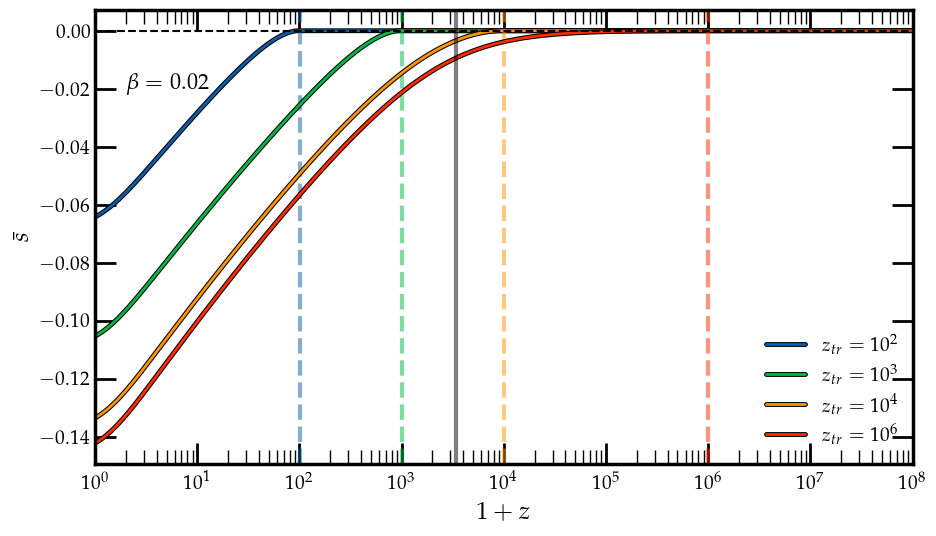

In [122]:
plt.style.use('/mnt/e/Workplace/sty.mplstyle')

plt.figure(figsize=(10, 6))

# Plot each line with a color from the colormap
for z_tr in z_tr_list:
    plt.semilogx(
        1 + z[z_tr],
        phi_scf[z_tr] * np.sqrt(beta / 2),
        label=rf'$z_{{tr}}=10^{np.log10(z_tr):.0f}$',
        linewidth=2,
        path_effects=[pe.withStroke(linewidth=3.5, foreground='black')]
    )
    z_color = plt.gca().lines[-1].get_color()
    plt.axvline(x=1+z_tr, linestyle='--',  alpha=0.5, color=z_color)
    
# Axis labels
plt.xlabel(r'$1+z$', fontsize=18)
plt.ylabel(r'$\bar{s}$', fontsize=18)

# Reference lines
plt.axvline(x=3400, color='black', linestyle='-', alpha=0.5)
plt.axhline(y=1e-4, xmin=0, xmax=1, color='black', linestyle='--', linewidth=1.5)

# Limits and ticks
plt.xlim(1, 1e8)
#plt.ylim(-0.002, 0.001)
plt.tick_params(axis='both', which='both', labelsize=14)
plt.legend(fontsize=14, loc='lower right', framealpha=1)
plt.text(2, -2e-2, r'$\beta=0.02$', fontsize=16)
# Layout and save
plt.tight_layout()
plt.savefig("one_beta_scalar_field.pdf")
plt.show()

In [82]:
# import numpy as np
# import matplotlib.pyplot as plt

# def cosine_transition(a, z_tr, width=1.0):
#     a_tr = 1.0 / (1.0 + z_tr)
#     loga = np.log(a)
#     loga_tr = np.log(a_tr)

#     # Use np.where to handle arrays
#     return np.where(
#         loga < loga_tr, 
#         0.0,
#         np.where(
#             loga > loga_tr + 2 * width,
#             1.0,
#             0.5 * (1.0 + np.cos(np.pi * (loga - loga_tr) / (2.0 * width) + np.pi))
#         )
#     )
    
# def m_chi(a, beta, phi, z_tr):
#     G_S_effective = beta / 2 * cosine_transition(a, z_tr)
#     return np.sqrt(1 + 2 * np.sqrt(G_S_effective) * phi)

# def dlogm_chi_dlogs(a, beta, phi, z_tr):
#     G_S_effective = beta / 2 * cosine_transition(a, z_tr)
#     denom = 1 + 2 * np.sqrt(G_S_effective) * phi
#     return 1 / denom

# # Example plotting
# fig, ax = plt.subplots(figsize=(8, 5))

# phi_vals = phi_scf[z_tr_list[-1]]  # vector of phi values
# a_test = 1 / (1 + z[z_tr_list[-1]])     # scalar
# beta = 0.005

# m_vals = m_chi(a, beta, phi_vals, z_tr_list[-1])  # now vectorized
# dlogm_vals = dlogm_chi_dlogs(a, beta, phi_vals, z_tr_list[-1])  # now vectorized
# ax.plot(phi_vals * np.sqrt(beta / 2), 1 / dlogm_vals, label=f'$\\beta={beta}$')
# ax.plot(phi_vals * np.sqrt(beta / 2), m_vals, label=f'$\\beta={beta}$')

# ax.set_xlabel(r"$\bar{s}$")
# ax.set_ylabel(r"$\frac{d \log m}{d \log s}$")
# ax.set_xscale('linear')
# # ax.set_ylim(0.9999, 1.00025)
# ax.legend()
# plt.show()

# fig, ax = plt.subplots(figsize=(8, 5))
# a_vals = np.logspace(-10, 0, 1000)
# z_tr_example = 1e4
# transition_vals = cosine_transition(a_vals, z_tr_example)
# ax.plot(a_vals, transition_vals, label=f'$z_{{tr}}={z_tr_example}$')
# ax.set_xscale('log')
# ax.set_xlabel('Scale Factor (a)', fontsize=14)
# ax.set_ylabel('Transition Function', fontsize=14)
# ax.set_title('Cosine Transition Function', fontsize=16)
# #ax.axvline(x=1/(1+z_tr_example), color='red', linestyle='--', label='$a_{tr}$')
# ax.legend()
# ax.set_xlim(1e-5, 1e-3)
# plt.grid()
# plt.tight_layout()
# plt.show()


/tmp/ipykernel_1409/2932256175.py:39: RuntimeWarning: invalid value encountered in divide
  comov_line = axs[3].semilogx(1 + z[z_tr], comov[z_tr] / comov_lcdm_interp, linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], label=rf'$z_{{tr}}={z_tr}$')#, color=color)


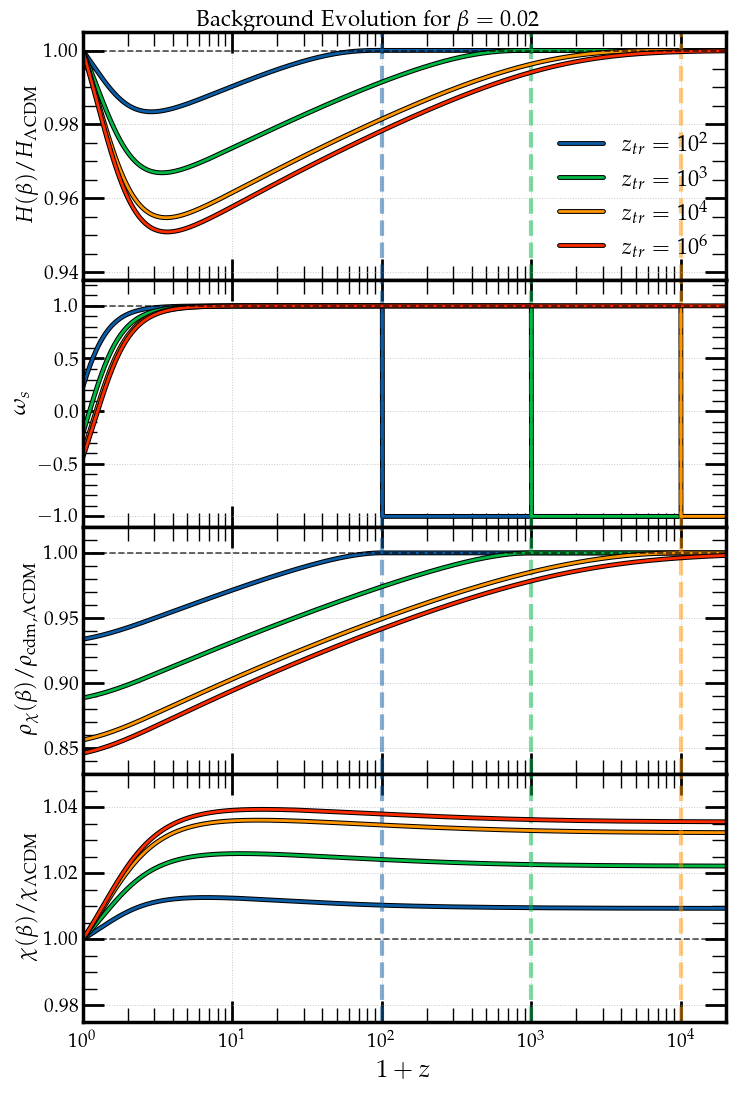

In [124]:
from scipy.interpolate import interp1d

# Set up figure
fig, axs = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

# Interpolation functions
interp_H_lcdm = interp1d(z_lcdm, H_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')
interp_rho_cdm_lcdm = interp1d(z_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')
interp_comov_lcdm = interp1d(z_lcdm, comov_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

# Loop over z_tr values
for z_tr in z_tr_list:

    # Interpolated LCDM quantities onto z[z_tr] grid
    H_lcdm_interp = interp_H_lcdm(z[z_tr])
    rho_cdm_lcdm_interp = interp_rho_cdm_lcdm(z[z_tr])
    comov_lcdm_interp = interp_comov_lcdm(z[z_tr])
    
    color = cmap(norm(z_tr))

    # Plot 1: H[z_tr] / H_lcdm
    H_line = axs[0].semilogx(1 + z[z_tr], H[z_tr] / H_lcdm_interp, linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], label=rf'$z_{{tr}}=10^{np.log10(z_tr):.0f}$', 
                    #color=color
                    )
    axs[0].set_ylim(0.938, 1.005) #original lower limit 0.938
    axs[0].vlines(x=1+z_tr, ymin=axs[0].get_ylim()[0], ymax=axs[0].get_ylim()[1], color = H_line[0].get_color(), linestyles='--', alpha=0.5)

    # Plot 2: omega_scf[z_tr]
    scf_line = axs[1].semilogx(1 + z[z_tr], p_scf[z_tr] / rho_scf[z_tr], linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], label=rf'$z_{{tr}}={z_tr}$') #color=color
    axs[1].set_ylim(-1.1, 1.25)
    axs[1].vlines(x=1+z_tr, ymin=axs[1].get_ylim()[0], ymax=axs[1].get_ylim()[1], color = scf_line[0].get_color(), linestyles='--', alpha=0.5)

    # Plot 3: rho_cdm[z_tr] / rho_cdm_lcdm
    rho_line = axs[2].semilogx(1 + z[z_tr], rho_chi[z_tr] / rho_cdm_lcdm_interp, linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], label=rf'$z_{{tr}}={z_tr}$')# color=color)
    axs[2].set_ylim(0.83, 1.02) #original lower limit 0.83
    axs[2].vlines(x=1+z_tr, ymin=axs[2].get_ylim()[0], ymax=axs[2].get_ylim()[1], color = rho_line[0].get_color(), linestyles='--', alpha=0.5)

    # Plot 4: comov[z_tr] / comov_lcdm
    comov_line = axs[3].semilogx(1 + z[z_tr], comov[z_tr] / comov_lcdm_interp, linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], label=rf'$z_{{tr}}={z_tr}$')#, color=color)
    axs[3].set_ylim(0.975, 1.05) #original upper limit 1.05
    axs[3].vlines(x=1+z_tr, ymin=axs[3].get_ylim()[0], ymax=axs[3].get_ylim()[1], color = comov_line[0].get_color(), linestyles='--', alpha=0.5)
    
        
    
# Common plot settings
titles = [
    r'$H(\beta)/H_{\Lambda\mathrm{CDM}}$',
    r'$\omega_s$',
    r'$\rho_{\chi}(\beta)/\rho_{\mathrm{cdm},\Lambda\mathrm{CDM}}$',
    r'$\chi(\beta)/\chi_{\Lambda\mathrm{CDM}}$'
]

for i, ax in enumerate(axs):
    ax.set_ylabel(titles[i], fontsize=16)
    ax.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)  # reference line at 1 (for ratios)
    ax.set_xlim(1, 2e4)
    if i == 0:
        ax.legend(fontsize=16, loc='lower right', frameon=False)
    #ax.legend(fontsize=16, loc='lower right', frameon=False)

# X-axis label only on bottom plot
axs[-1].set_xlabel(r'$1+z$', fontsize=18)
fig.suptitle(r'Background Evolution for $\beta=0.02$', fontsize=16, y=0.93) 

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(hspace=0.0)

plt.show()

# Save the figure
fig.savefig('one_beta_background.pdf', dpi=300, bbox_inches='tight')

/tmp/ipykernel_1409/1668581111.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


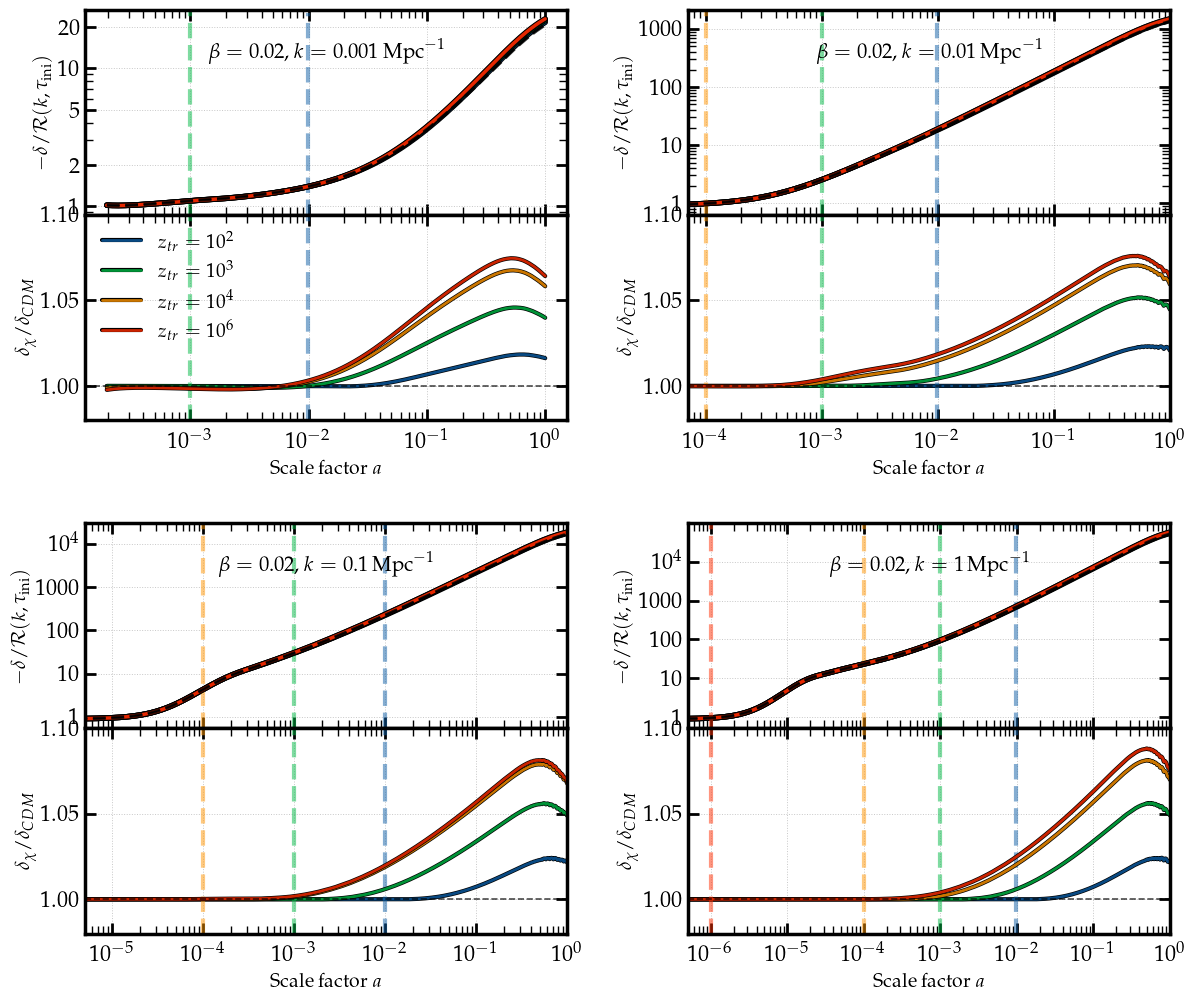

In [118]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib.patheffects as pe


ks = k_values  # Example k values

fig = plt.figure(figsize=(14, 12))
outer = GridSpec(2, 2, wspace=0.25, hspace=0.25)

for idx, k in enumerate(ks):
    row, col = divmod(idx, 2)
    inner = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[idx], height_ratios=[2, 2], hspace=0.0)

    ax1 = fig.add_subplot(inner[0])
    ax2 = fig.add_subplot(inner[1], sharex=ax1)

    # Interpolation function for LCDM
    interp_lcdm = interp1d(a_lcdm[k], delta_cdm_lcdm[k], kind='linear', bounds_error=False, fill_value='extrapolate')

    for z_tr in z_tr_list:

        # Plot delta
        delta_line = ax1.loglog(a[z_tr, k], -delta_chi[z_tr, k], 
            label=rf'$z_{{tr}} = 10^{np.log10(z_tr):.0f}$',
            linewidth=2.5, path_effects=[pe.withStroke(linewidth=4, foreground='black')], alpha=0.9
        )
        
        ax1.vlines(x=1/(1+z_tr), ymin=ax1.get_ylim()[0], ymax=ax1.get_ylim()[1], color = delta_line[0].get_color(), linestyles='--', alpha=0.5)
        
        # Interpolate LCDM delta
        delta_lcdm_interp = interp_lcdm(a[z_tr, k])
        ratio = delta_cdm[z_tr, k] / delta_lcdm_interp

        # Plot ratio
        ratio_line = ax2.semilogx(a[z_tr, k], ratio, 
            label=rf'$z_{{tr}} = 10^{np.log10(z_tr):.0f}$',
            linewidth=2.0, path_effects=[pe.withStroke(linewidth=3, foreground='black')], alpha=0.8
        )
        
        ax2.vlines(x=1/(1+z_tr), ymin=0.98, ymax=1.1, color = ratio_line[0].get_color(), linestyles='--', alpha=0.5)
    

    ax1.loglog(a[z_tr, k], -delta_lcdm_interp, 
        label=rf'$\Lambda$CDM', 
        linewidth=2.5, linestyle='--', alpha=0.8, color='black', path_effects=[pe.withStroke(linewidth=1, foreground='black')]
    )
    
    # LCDM lines
    #ax1.loglog(a_lcdm[k], np.abs(delta_g_lcdm[k]), color='black', linestyle='--', linewidth=2, label=r'$\delta_\gamma$')
    #ax1.loglog(a_lcdm[k], np.abs(delta_cdm_lcdm[k]), color='black', linestyle='-.', linewidth=2, label=r'$\delta_\mathrm{cdm}$')
    
    ax2.axhline(1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

    ax1.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    ax2.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)

    if idx == 0:
        #ax2.set_xlim(1e-5, 1)
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 2.0, 5.0, 10, 20)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '2', '5', '10', '20']))
        ax2.legend(fontsize=14, loc='upper left', frameon=False)
    if idx == 1:
        ax2.set_xlim(7e-5, 1)
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 10.0, 100.0, 1000)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '10', '100', '1000']))
    if idx == 2:
        ax2.set_xlim(5e-6, 1)
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 10.0, 100.0, 1000, 10000)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '10', '100', '1000', r'$10^4$']))
    if idx == 3:
        ax2.set_xlim(5e-7, 1)
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 10.0, 100.0, 1000, 10000)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '10', '100', '1000', r'$10^4$']))

    ax2.set_ylim(0.98, 1.1)
    #hide x-tick labels for ax1
    ax1.tick_params(axis='x', which='both', labelbottom=False)
    ax1.tick_params(axis='both', which='major', labelsize=16, length=8)
    ax2.tick_params(axis='both', which='major', labelsize=16, length=8)
    ax1.tick_params(axis='both', which='minor', labelsize=16, length=6)
    ax2.tick_params(axis='both', which='minor', labelsize=16, length=6)
    #ax2.yaxis.set_major_locator(FixedLocator((1.0, 1.05, 1.1, 1.15)))
    #ax2.set_ylim(0.98, 1.16)

    ax2.set_xlabel(r'Scale factor $a$', fontsize=14)
    ax1.set_ylabel(r'$-\delta/\mathcal{R}(k, \tau_\mathrm{ini})$', fontsize=14)
    ax2.set_ylabel(r'$\delta_\chi/\delta_{CDM}$', fontsize=14)
    
    #ax1.legend(fontsize=14, loc='lower right', frameon=False)
    ax1.text(0.5, 0.8, rf'$\beta={beta}, k = {k}\,\mathrm{{Mpc}}^{{-1}}$', fontsize=15, ha='center', va='center', transform=ax1.transAxes)
    #ax1.set_title(rf'$k = {k:.0e}\,\mathrm{{Mpc}}^{{-1}}$', fontsize=15)

# Shared legend
# handles, labels = ax1.get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', fontsize=14, ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('one_beta_delta_chi.pdf', dpi=300, bbox_inches='tight')
plt.show()

92666 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
99934 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
101483 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
91441 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


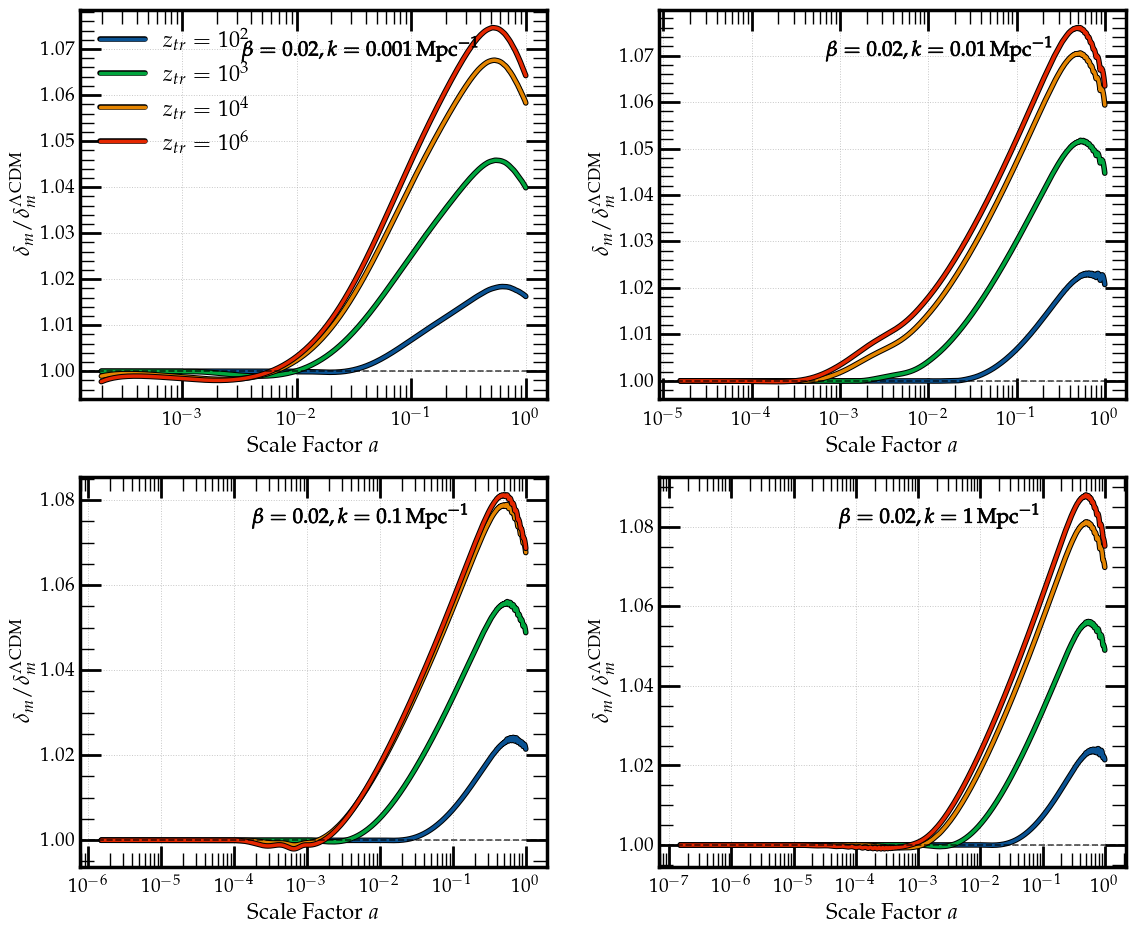

In [85]:
from scipy.interpolate import interp1d

# Set up figure
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=False)
axs = axs.flatten()

for i, k in enumerate(k_values):
    for z_tr in z_tr_list:
        
        # Interpolate LCDM delta onto a[beta] grid
        interp_lcdm = interp1d(a_lcdm[k], delta_m_lcdm[k], kind='linear', bounds_error=False, fill_value='extrapolate')
        delta_m_interp = interp_lcdm(a[z_tr, k])
        
        # Compute the ratio
        ratio = (delta_m[z_tr, k]) / delta_m_interp 
        if k == 1:
            print(len(ratio), ratio[:20])
        
        # Plot
        axs[i].semilogx(
            a[z_tr, k], 
            ratio, 
            label=rf'$z_{{tr}} = 10^{np.log10(z_tr):.0f}$', 
            linewidth=2.5,
            path_effects=[pe.withStroke(linewidth=4, foreground='black')],
            alpha=0.9, 
            #color = cmap(norm(z_tr))
        )

for i, ax in enumerate(axs):
    ax.set_ylabel(r'$\delta_m/\delta_m^{\Lambda\mathrm{CDM}}$', fontsize=16)
    ax.set_xlabel(r'Scale Factor $a$', fontsize=16)
    ax.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)  # reference line at 1 (for ratios)
    #ax.set_xlim(1, 4000)
    ax.text(0.6, 0.9, rf'$\beta={beta}, k = {k_values[i]}\,\mathrm{{Mpc}}^{{-1}}$', fontsize=15, ha='center', va='center', transform=ax.transAxes, 
            path_effects=[pe.withStroke(linewidth=0.5, foreground='black')])
    if i == 0:
        ax.legend(fontsize=16, loc='upper left', frameon=False)
    # if i == 2 or i == 3:
    #     ax.set_xlim(1e-6, 1e-4)
    #     ax.set_ylim(0.998, 1.001)

# # X-axis label only on bottom plot
# axs[-1].set_xlabel(r'$1+z$', fontsize=18)
fig.savefig('delta_m.pdf', dpi=300, bbox_inches='tight')

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)

plt.show()

# Save the figure
#fig.savefig('beta_lrm_comparison.pdf', dpi=300, bbox_inches='tight')

1050.1108424652352


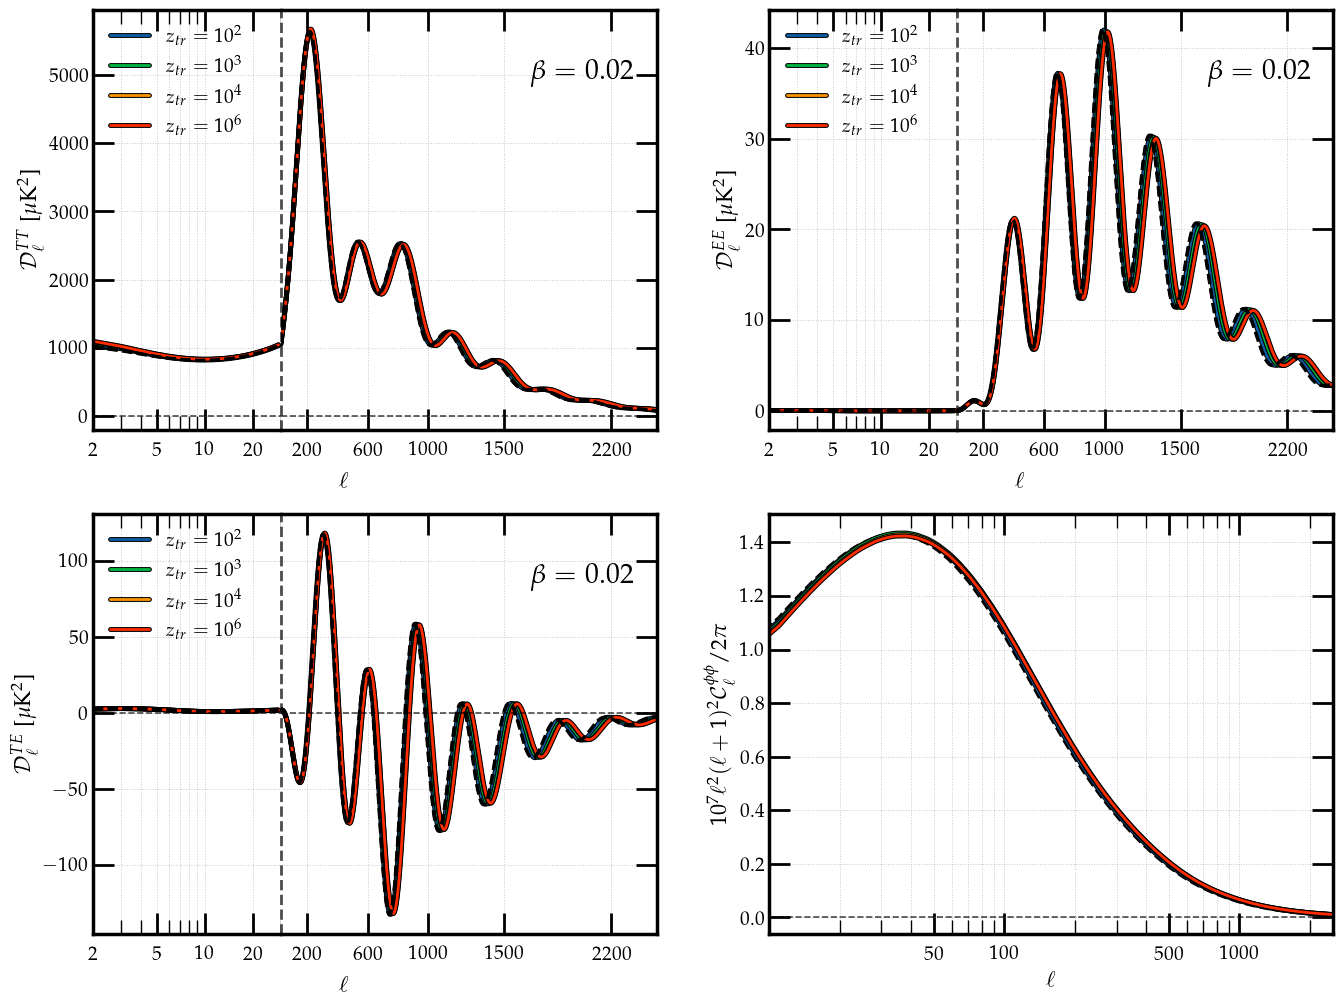

In [125]:
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter

### Plot the power spectra with split-axis approach
T0 = 2.7255  # CMB temperature in K

# Create figure with custom layout
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], wspace=0.2, hspace=0.2)

# Subplot configurations
subplot_configs = [
    (0, 'TT', clTT, r'$\mathcal{D}_\ell^{TT}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell*(ell+1)/(2*np.pi)*1e12*T0**2),
    (1, 'EE', clEE, r'$\mathcal{D}_\ell^{EE}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell*(ell+1)/(2*np.pi)*1e12*T0**2),
    (2, 'TE', clTE, r'$\mathcal{D}_\ell^{TE}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell*(ell+1)/(2*np.pi)*1e12*T0**2),
    (3, 'PP', clPP, r'$10^{7}\ell^2(\ell+1)^2\mathcal{C}_\ell^{\phi\phi}/2\pi$', lambda cl, ell: cl*(ell*(ell+1))**2/(2*np.pi)*1e7)
]

# Custom plotting function for split-axis plots
def create_split_axis_subplot(fig, gs, row_col, ell, cl, label_func, ylabel, is_pp=False):
    # Create subplot grid
    if is_pp:
        # PP plot uses standard log scale
        ax = fig.add_subplot(gs[row_col])
        ax.set_xscale('log')
        ax.set_xlim(10, 2500)
        ax_log = ax
        ax.plot(ll_lcdm, clPP_lcdm*(ll_lcdm*(ll_lcdm+1))**2/(2*np.pi)*1e7, linewidth=2, label= rf'$\Lambda$CDM', ls='--', color = 'black', 
                    path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
        for z_tr in z_tr_list:
            ax.plot(ell[z_tr], cl[z_tr]*(ell[z_tr]*(ell[z_tr]+1))**2/(2*np.pi)*1e7, linewidth=2, label= rf'$\beta = {beta}$', 
                    path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.set_xlabel(r'$\ell$', fontsize=16)
        ax.set_ylabel(r'$10^{7}\ell^2(\ell+1)^2\mathcal{C}_\ell^{\phi\phi}/2\pi$', fontsize=16)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.set_xticks([50, 100, 500, 1000])
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
        return ax
    
    # Create GridSpec for split-axis plots
    gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row_col], 
                                               width_ratios=[1, 2], wspace=0.0)
    
    # Left subplot (log scale)
    ax_log = fig.add_subplot(gs_sub[0])
    ax_log.set_xscale('log')
    ax_log.set_xlim(2, 30)
    
    # Right subplot (linear scale)
    ax_lin = fig.add_subplot(gs_sub[1], sharey=ax_log)
    ax_lin.set_xlim(30, 2500)
    
    # Remove spines between the two plots
    ax_log.spines['right'].set_visible(False)
    ax_lin.spines['left'].set_visible(False)
    ax_log.yaxis.tick_left()
    ax_lin.yaxis.tick_right()

    
    # Plot spectra for each beta
    for z_tr in z_tr_list:
        # Prepare data masks
        mask_log = ell[z_tr] < 30
        mask_lin = ell[z_tr] >= 30
        
        # Compute plotted values
        D_ell_log = label_func(cl[z_tr][mask_log], ell[z_tr][mask_log])
        D_ell_lin = label_func(cl[z_tr][mask_lin], ell[z_tr][mask_lin])
        
        # Line properties
        line_kwargs = {
            'linewidth': 2, 
            'path_effects': [pe.withStroke(linewidth=3.5, foreground='black')],
            'label': rf'$z_{{tr}} = 10^{np.log10(z_tr):.0f}$', 
            # 'color': cmap(norm(z_tr)) 
        }
        
        # Plot on both axes
        ax_log.plot(ell[z_tr][mask_log], D_ell_log, **line_kwargs)
        ax_lin.plot(ell[z_tr][mask_lin], D_ell_lin, **line_kwargs)
    if name == 'TT':
        ax_log.plot(ll_lcdm[mask_log], clTT_lcdm[mask_log]*ll_lcdm[mask_log]*(ll_lcdm[mask_log]+1)/(2*np.pi)*1e12*T0**2, 
                        linewidth=2, ls='--', color = 'black', 
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
        ax_lin.plot(ll_lcdm[mask_lin], clTT_lcdm[mask_lin]*ll_lcdm[mask_lin]*(ll_lcdm[mask_lin]+1)/(2*np.pi)*1e12*T0**2, 
                        linewidth=2, label= rf'$\Lambda$CDM', ls='--', color = 'black', 
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
        print((clTT_lcdm[mask_lin]*ll_lcdm[mask_lin]*(ll_lcdm[mask_lin]+1)/(2*np.pi)*1e12*T0**2)[0])
    if name == 'EE':
        ax_log.plot(ll_lcdm[mask_log], clEE_lcdm[mask_log]*ll_lcdm[mask_log]*(ll_lcdm[mask_log]+1)/(2*np.pi)*1e12*T0**2, 
                    linewidth=2, ls='--', color = 'black', 
                    path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
        ax_lin.plot(ll_lcdm[mask_lin], clEE_lcdm[mask_lin]*ll_lcdm[mask_lin]*(ll_lcdm[mask_lin]+1)/(2*np.pi)*1e12*T0**2, 
                        linewidth=2, label= rf'$\Lambda$CDM', ls='--', color = 'black', 
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
    if name == 'TE':
            ax_log.plot(ll_lcdm[mask_log], clTE_lcdm[mask_log]*ll_lcdm[mask_log]*(ll_lcdm[mask_log]+1)/(2*np.pi)*1e12*T0**2, 
                        linewidth=2, ls='--', color = 'black', 
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            ax_lin.plot(ll_lcdm[mask_lin], clTE_lcdm[mask_lin]*ll_lcdm[mask_lin]*(ll_lcdm[mask_lin]+1)/(2*np.pi)*1e12*T0**2, 
                        linewidth=2, label= rf'$\Lambda$CDM', ls='--', color = 'black', 
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
    
    # Formatting
    ax_log.set_ylabel(ylabel, fontsize=16)
    ax_lin.text(0.8, 0.85, rf"$\beta={beta}$", fontsize=20, ha='center', va='center', transform=ax_lin.transAxes)
    ax_lin.set_xlabel(r'$\ell$', fontsize=16)
    ax_lin.xaxis.set_label_coords(1/6, -0.1)
    for ax in [ax_log, ax_lin]:
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.axvline(x=30, color='black', linestyle='--', linewidth=2, alpha=0.7)
        ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Tick formatting
    ax_log.set_xticks([2, 5, 10, 20])
    ax_lin.set_xticks([200, 600, 1000, 1500, 2200])
    for ax in [ax_log, ax_lin]:
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
    
    # Tick visibility
    ax_log.tick_params(labelleft=True, labelright=False)
    ax_lin.tick_params(labelleft=False, labelright=False)
    
    # Legend
    ax_log.legend(fontsize=14, loc='upper left', frameon=False)
    
    return ax_log, ax_lin

# Create subplots
for (idx, name, cl_dict, ylabel, label_func) in subplot_configs:
    is_pp = (name == 'PP')
    if is_pp:
        # PP plot is different (standard log scale)
        ax = create_split_axis_subplot(fig, gs, idx, ll, cl_dict, label_func, ylabel, is_pp=True)
        #ax.legend(fontsize=16, loc='upper right', frameon=False)
    else:
        # TT, EE, TE plots use split-axis
        create_split_axis_subplot(fig, gs, idx, ll, cl_dict, label_func, ylabel)
        
fig.savefig('one_beta_power_spectra.pdf', dpi=300, bbox_inches='tight')


#plt.tight_layout()
plt.show()

/tmp/ipykernel_1409/1594201598.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


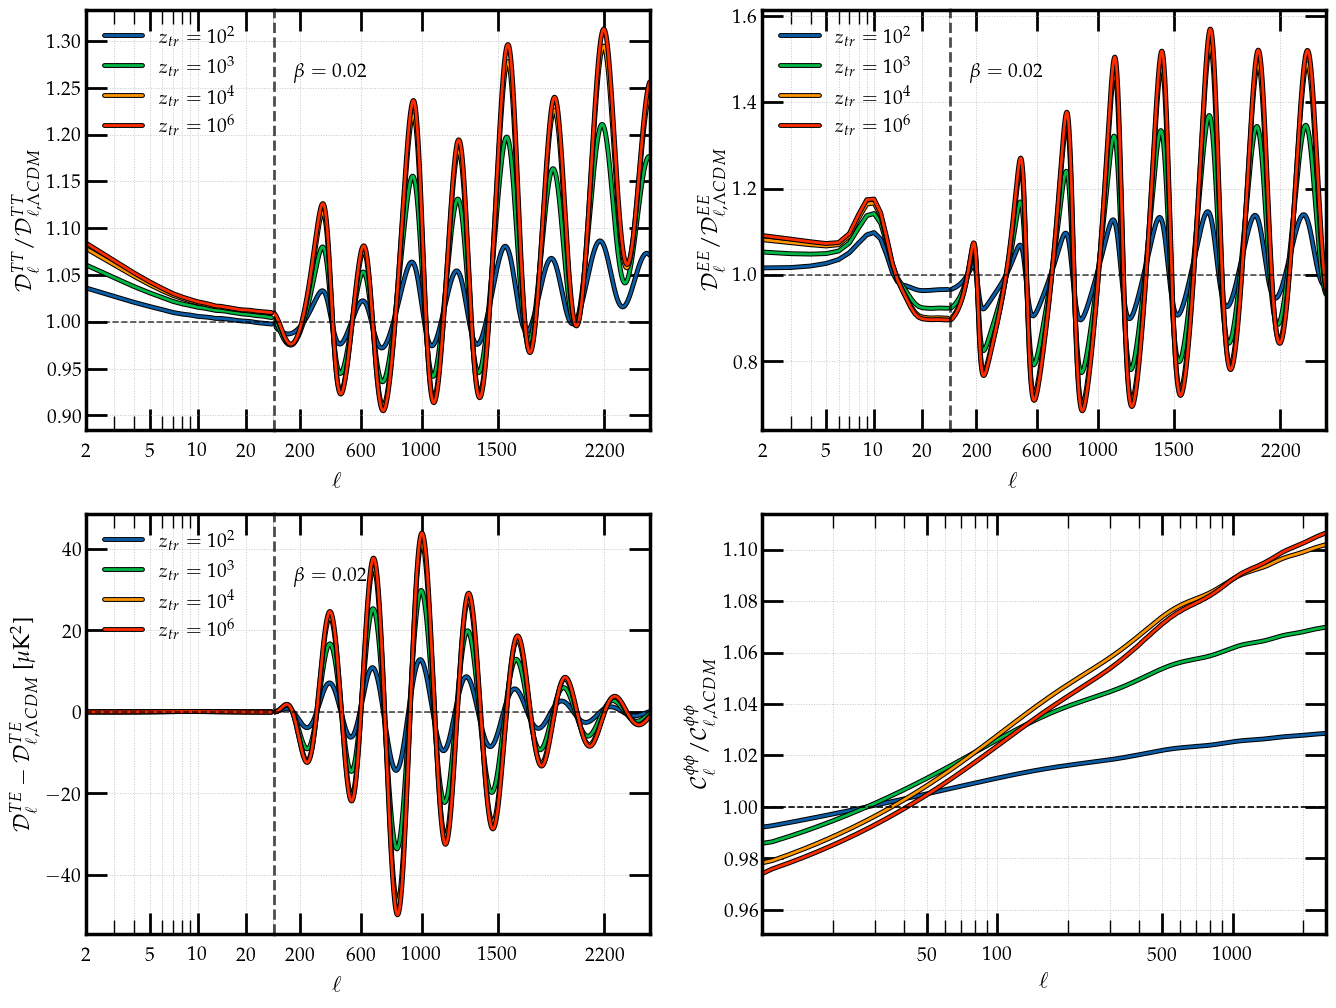

In [127]:
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter

### Plot the power spectra with split-axis approach
T0 = 2.7255  # CMB temperature in K

# Create figure with custom layout
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], wspace=0.2, hspace=0.2)

# Subplot configurations
subplot_configs = [
    (0, 'TT', clTT, clTT_lcdm, r'$\mathcal{D}_\ell^{TT}/\mathcal{D}_{\ell, \Lambda CDM}^{TT}$', lambda cl, clTT_lcdm: cl/clTT_lcdm),
    (1, 'EE', clEE, clEE_lcdm, r'$\mathcal{D}_\ell^{EE}/\mathcal{D}_{\ell, \Lambda CDM}^{EE}$', lambda cl, clEE_lcdm: cl/clEE_lcdm),
    (2, 'TE', clTE, clTE_lcdm, r'$\mathcal{D}_\ell^{TE}-\mathcal{D}_{\ell, \Lambda CDM}^{TE}$ [$\mu$K$^2$]', lambda cl, clTE_lcdm, ell: (cl-clTE_lcdm)*ell*(ell+1)/(2*np.pi)*1e12*T0**2),
    (3, 'PP', clPP, clPP_lcdm, r'$\mathcal{C}_\ell/\mathcal{C}_{\ell, \Lambda CDM}$', lambda cl, clPP_lcdm: cl/clPP_lcdm)
]

# Custom plotting function for split-axis plots
def create_split_axis_subplot(fig, gs, row_col, ell, cl, cl_lcdm, label_func, ylabel, is_pp=False, is_te=False):
    # Create subplot grid
    if is_pp:
        # PP plot uses standard log scale
        ax = fig.add_subplot(gs[row_col])
        ax.set_xscale('log')
        ax.set_xlim(10, 2500)
        ax_log = ax
        for z_tr in z_tr_list:
            ax.plot(ell[z_tr], cl[z_tr]/cl_lcdm, linewidth=2, label= rf'$z_{{tr}} = {z_tr}$', 
                    path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
        ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.set_xlabel(r'$\ell$', fontsize=16)
        ax.set_ylabel(r'$\mathcal{C}^{\phi\phi}_\ell/\mathcal{C}^{\phi\phi}_{\ell, \Lambda CDM}$', fontsize=16)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.set_xticks([50, 100, 500, 1000])
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
        return ax
    
    # Create GridSpec for split-axis plots
    gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row_col], 
                                               width_ratios=[1, 2], wspace=0.0)
    
    # Left subplot (log scale)
    ax_log = fig.add_subplot(gs_sub[0])
    ax_log.set_xscale('log')
    ax_log.set_xlim(2, 30)
    
    # Right subplot (linear scale)
    ax_lin = fig.add_subplot(gs_sub[1], sharey=ax_log)
    ax_lin.set_xlim(30, 2500)
    
    # Remove spines between the two plots
    ax_log.spines['right'].set_visible(False)
    ax_lin.spines['left'].set_visible(False)
    ax_log.yaxis.tick_left()
    ax_lin.yaxis.tick_right()

    
    # Plot spectra for each beta
    for z_tr in z_tr_list:
        # Prepare data masks
        mask_log = ell[z_tr] < 30
        mask_lin = ell[z_tr] >= 30
        
        # Compute plotted values
        if idx == 2:
            D_ell_log = label_func(cl[z_tr][mask_log], cl_lcdm[mask_log], ell[z_tr][mask_log])
            D_ell_lin = label_func(cl[z_tr][mask_lin], cl_lcdm[mask_lin], ell[z_tr][mask_lin])
        else:
            D_ell_log = label_func(cl[z_tr][mask_log], cl_lcdm[mask_log])
            D_ell_lin = label_func(cl[z_tr][mask_lin], cl_lcdm[mask_lin])
        
        # Line properties
        line_kwargs = {
            'linewidth': 2, 
            'path_effects': [pe.withStroke(linewidth=3.5, foreground='black')],
            'label': rf'$z_{{tr}} = 10^{np.log10(z_tr):.0f}$', 
            #'color': cmap(norm(z_tr))
        }
        
        # Plot on both axes
        ax_log.plot(ell[z_tr][mask_log], D_ell_log, **line_kwargs)
        ax_lin.plot(ell[z_tr][mask_lin], D_ell_lin, **line_kwargs)
    
    # Formatting
    ax_log.set_ylabel(ylabel, fontsize=16)
    ax_lin.set_xlabel(r'$\ell$', fontsize=16)
    ax_lin.xaxis.set_label_coords(1/6, -0.1)
    for ax in [ax_log, ax_lin]:
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        if is_te:
            ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        else:
            ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.axvline(x=30, color='black', linestyle='--', linewidth=2, alpha=0.7)
        ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Tick formatting
    ax_log.set_xticks([2, 5, 10, 20])
    ax_lin.set_xticks([200, 600, 1000, 1500, 2200])
    for ax in [ax_log, ax_lin]:
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
    
    # Tick visibility
    ax_log.tick_params(labelleft=True, labelright=False)
    ax_lin.tick_params(labelleft=False, labelright=False)
    
    # Legend
    ax_lin.text(0.05, 0.85, rf"$\beta={beta}$", fontsize=14, ha='left', va='center', transform=ax_lin.transAxes)
    ax_log.legend(fontsize=14, loc='upper left', frameon=False)
    
    return ax_log, ax_lin

# Create subplots
for (idx, name, cl_dict, cl_lcdm_dict, ylabel, label_func) in subplot_configs:
    is_pp = (name == 'PP')
    if is_pp:
        # PP plot is different (standard log scale)
        ax = create_split_axis_subplot(fig, gs, idx, ll, cl_dict, cl_lcdm_dict, label_func, ylabel, is_pp=True)
        ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        #ax.legend(fontsize=16, loc='upper left', frameon=False)
    else:
        # TT, EE, TE plots use split-axis
        is_te = (name == 'TE')
        if is_te:
            create_split_axis_subplot(fig, gs, idx, ll, cl_dict, cl_lcdm_dict, label_func, ylabel, is_te=True)
        else:
            create_split_axis_subplot(fig, gs, idx, ll, cl_dict, cl_lcdm_dict, label_func, ylabel)

fig.savefig(f'one_beta_power_spectra_ratios.pdf', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()